In [34]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [35]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
from src.utils import split_pa_train_test_spatially, split_pa_train_test_kmeans
from src.pa_split import partition_sweep
from k_means_constrained import KMeansConstrained
from sklearn.metrics import pairwise_distances

In [36]:
import geopandas as gpd

def naturalearth_country(country_name="France", scale="110m", metropolitan_only=True):
    world = gpd.read_file(
        f"https://naturalearth.s3.amazonaws.com/{scale}_cultural/ne_{scale}_admin_0_countries.zip"
    )
    country = world[world["NAME"] == country_name]
    if country.empty:
        raise ValueError(f"'{country_name}' not found in Natural Earth NAME field.")

    geom = country.geometry.iloc[0]

    # Natural Earth "France" includes overseas parts; isolate mainland
    if metropolitan_only and country_name == "France":
        if geom.geom_type == "MultiPolygon":
            parts = gpd.GeoDataFrame(geometry=list(geom.geoms), crs=country.crs)
        else:
            parts = gpd.GeoDataFrame(geometry=[geom], crs=country.crs)

        # Use a point guaranteed to lie inside each polygon (safe in lon/lat)
        pts = parts.geometry.representative_point()

        # Mainland-France bbox in lon/lat
        # parts = parts[pts.x.between(-6, 10) & pts.y.between(41, 52)]
        # Mainland-France bbox + explicit Corsica removal
        parts = parts[
            pts.x.between(-6, 8.7) &   # <-- tighten eastern bound
            pts.y.between(41, 52)
        ]


        if parts.empty:
            raise ValueError("Could not isolate metropolitan France from geometry parts.")

        # union_all is the recommended replacement for unary_union
        geom = parts.geometry.union_all() if hasattr(parts.geometry, "union_all") else parts.unary_union

    return gpd.GeoDataFrame({"NAME": [country_name]}, geometry=[geom], crs=country.crs)

# --- build France border from Natural Earth ---
gdf_map = naturalearth_country("France", scale="50m", metropolitan_only=True)


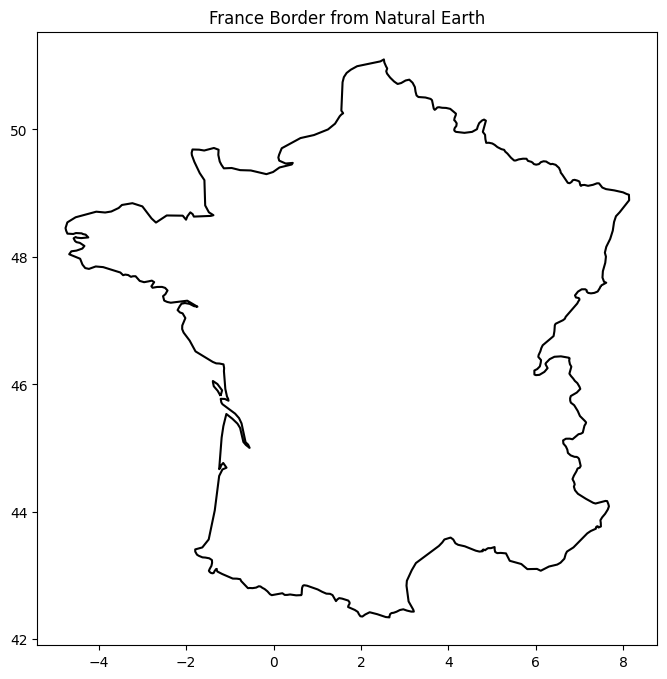

In [37]:
# plot france
fig, ax = plt.subplots(figsize=(8, 8))
gdf_map.boundary.plot(ax=ax, color="black")
ax.set_title("France Border from Natural Earth")
plt.show()

In [40]:
# pa path: data/processed/geoplant/france_sparse_0.05_0.05/X_pa_france_covs.csv

X_pa = pd.read_csv("data/processed/geoplant/france_sparse_0.4_0.1/X_pa_france_covs.csv")
X_po = pd.read_csv("data/processed/geoplant/france_sparse_0.4_0.1/X_po_france_covs.csv")

covs_distance = ["lat", "lon"]


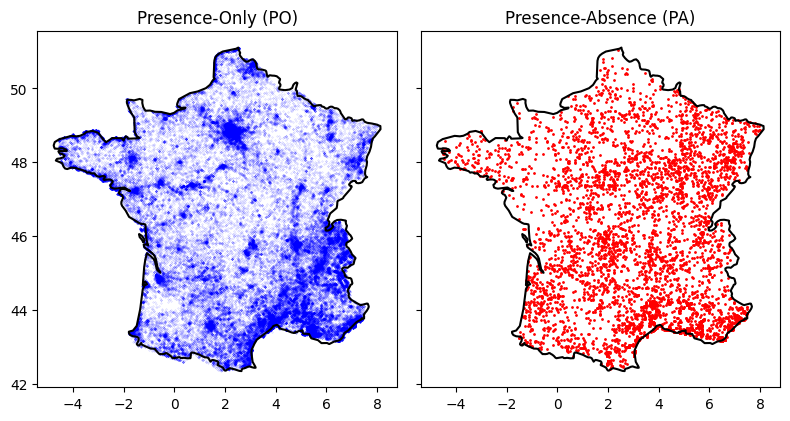

In [52]:
# Plot of PO and PA with 2 subfigures side by side with France border
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8), sharey=True)   
gdf_map.boundary.plot(ax=ax1, color="black")
ax1.scatter(X_po["lon"], X_po["lat"], s=.05, color="blue", label="PO Points", alpha = 0.3)
ax1.set_title("Presence-Only (PO)")         
gdf_map.boundary.plot(ax=ax2, color="black")
ax2.scatter(X_pa["lon"], X_pa["lat"], s=1, color="red", label="PA Points")
ax2.set_title("Presence-Absence (PA)")
# tight layout
plt.tight_layout()
plt.show()

In [29]:

X_matrix = X_pa[covs_distance].to_numpy()
# print(X_matrix.shape)
# print(X_matrix[:5, :])
# print(X_matrix.std(axis=0))
# print(covs_distance)

# --- compute ONE global VI (same metric everywhere) ---
C = np.cov(X_matrix.T)
VI = np.linalg.pinv(C)   # robust to singularity; or use inv(C + eps*I)

## if any var has zero std, remove it
stds = X_matrix.std(axis=0)
zero_std_vars = [covs_distance[i] for i, s in enumerate(stds) if s < 1e-6]
if len(zero_std_vars) > 0:
    print(f"Removing zero-std variables from distance covariates: {zero_std_vars}")
    covs_distance = [c for c in covs_distance if c not in zero_std_vars]


D = pairwise_distances(
    X_pa[covs_distance].to_numpy(),
    metric='euclidean'
)

K_clusters = 10
n_samples = X_pa.shape[0]
print(f"Adjusted K_clusters to {K_clusters} due to small sample size.")
avg = n_samples / K_clusters
min_size = np.floor(avg)
max_size = np.ceil(avg)

print(f"Generating {K_clusters} clusters with sizes in [{min_size}, {max_size}]")
kmeans = KMeansConstrained(
    n_clusters=K_clusters,
    size_min=min_size,
    size_max=max_size,
    random_state=42,
    n_init=10,
)

Adjusted K_clusters to 10 due to small sample size.
Generating 10 clusters with sizes in [504.0, 505.0]


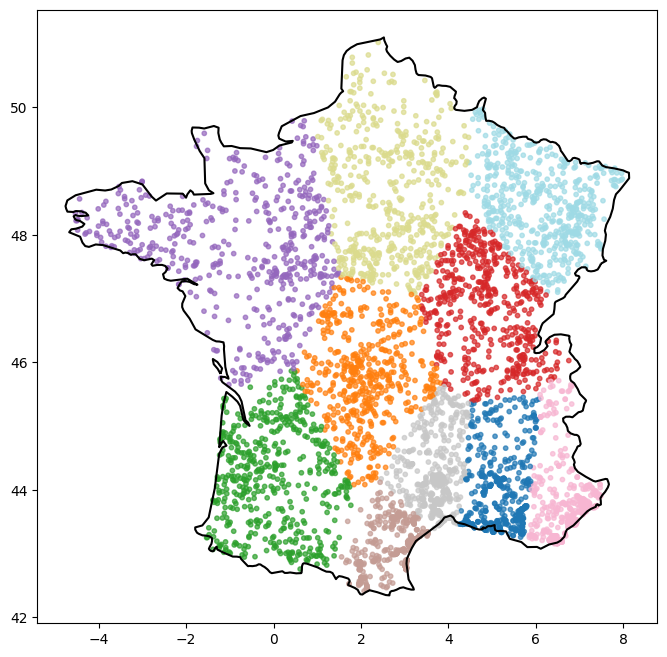

In [30]:
X_coords = X_pa[covs_distance].to_numpy()
labels = kmeans.fit_predict(X_coords)

X_clusters = X_pa.copy()
X_clusters["cluster"] = labels

# plot clusters
fig, ax = plt.subplots(figsize=(8, 8))
gdf_map.boundary.plot(ax=ax, color="black")
scatter = ax.scatter(
    X_clusters["lon"],
    X_clusters["lat"],
    c=X_clusters["cluster"],
    cmap="tab20",
    s=10,
    alpha=0.7,
)
# ax.set_title("KMeans-Constrained Clusters over France")
# plt.colorbar(scatter, ax=ax, label="Cluster")
plt.show()

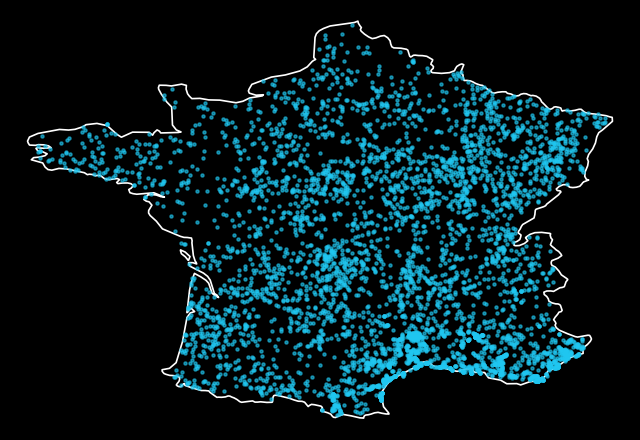

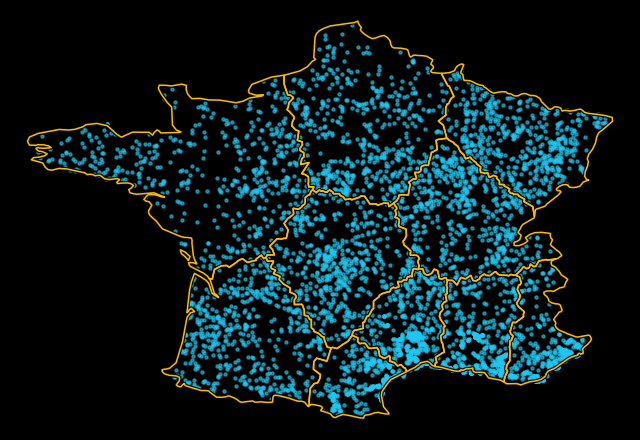

In [31]:
# --- ONE CELL: Voronoi cluster borders + neutral scatter, light/dark toggle ---
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from scipy.spatial import Voronoi

dark_version = True  

# Build point GeoDataFrame
gdf_pts = gpd.GeoDataFrame(
    X_clusters.copy(),
    geometry=gpd.points_from_xy(X_clusters["lon"], X_clusters["lat"]),
    crs=gdf_map.crs,
)

# Helper: finite Voronoi polygons
def voronoi_finite_polygons_2d(vor, radius=None):
    new_regions = []
    new_vertices = vor.vertices.tolist()
    center = vor.points.mean(axis=0)
    if radius is None:
        radius = vor.points.ptp().max() * 2

    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    for p1, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if all(v >= 0 for v in region):
            new_regions.append(region)
            continue

        ridges = all_ridges[p1]
        new_region = [v for v in region if v >= 0]

        for p2, v1, v2 in ridges:
            if v1 < 0 or v2 < 0:
                v = v1 if v1 >= 0 else v2
                t = vor.points[p2] - vor.points[p1]
                t /= np.linalg.norm(t)
                n = np.array([-t[1], t[0]])
                midpoint = (vor.points[p1] + vor.points[p2]) / 2
                direction = np.sign(np.dot(midpoint - center, n)) * n
                far_point = vor.vertices[v] + direction * radius
                new_vertices.append(far_point.tolist())
                new_region.append(len(new_vertices) - 1)

        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:, 1] - c[1], vs[:, 0] - c[0])
        new_region = [v for _, v in sorted(zip(angles, new_region))]
        new_regions.append(new_region)

    return new_regions, np.asarray(new_vertices)

# Voronoi → polygons → dissolve by cluster
coords = np.column_stack([gdf_pts.geometry.x, gdf_pts.geometry.y])
vor = Voronoi(coords)
regions, vertices = voronoi_finite_polygons_2d(vor, radius=100)

cells = [Polygon(vertices[r]) for r in regions]
gdf_cells = gpd.GeoDataFrame(
    {"cluster": gdf_pts["cluster"].to_numpy()},
    geometry=cells,
    crs=gdf_map.crs,
)

gdf_cells = gpd.clip(gdf_cells, gdf_map)
gdf_cluster_polys = gdf_cells.dissolve(by="cluster")




def save_cluster_fig_versions(
    gdf_map,
    gdf_pts,                 # GeoDataFrame with point geometry
    gdf_cluster_polys,       # GeoDataFrame/GeoSeries of dissolved cluster polygons
    path_base,               # e.g. "figs/france_points.png"
    path_with_borders,       # e.g. "figs/france_points_borders.png"
    dark_version=True,
    figsize=(8, 8),
    s=5,
    alpha=0.6,
    dpi=300,
    pad_frac=0.03,
):
    # ---- colors ----
    if dark_version:
        bg_color = "black"
        france_edge = "#ffffff"
        cluster_edge = "#feba00"
        halo_color = "#020617"
        point_color = "#20c7f1"
    else:
        bg_color = "white"
        france_edge = "black"
        cluster_edge = "#2563eb"
        halo_color = "white"
        point_color = "#374151"

    # handle GeoDataFrame vs GeoSeries for borders
    borders_geom = gdf_cluster_polys.geometry if hasattr(gdf_cluster_polys, "geometry") else gdf_cluster_polys

    def _render(add_borders=False):
        fig, ax = plt.subplots(figsize=figsize)
        fig.patch.set_facecolor(bg_color)
        ax.set_facecolor(bg_color)

        # France outline
        gdf_map.boundary.plot(ax=ax, color=france_edge, linewidth=1.2, zorder=1)

        # Points
        ax.scatter(
            gdf_pts.geometry.x,
            gdf_pts.geometry.y,
            s=s,
            color=point_color,
            alpha=alpha,
            zorder=2,
        )

        # Optional borders (draw last so they're on top)
        if add_borders:
            borders_geom.boundary.plot(ax=ax, color=halo_color, linewidth=2.8, zorder=4)
            borders_geom.boundary.plot(ax=ax, color=cluster_edge, linewidth=1.1, zorder=5)

        # Match your original plot scale
        minx, miny, maxx, maxy = gdf_map.total_bounds
        padx = (maxx - minx) * pad_frac
        pady = (maxy - miny) * pad_frac
        ax.set_xlim(minx - padx, maxx + padx)
        ax.set_ylim(miny - pady, maxy + pady)

        ax.set_aspect("equal")
        ax.set_axis_off()
        return fig

    # ensure directories exist
    os.makedirs(os.path.dirname(path_base) or ".", exist_ok=True)
    os.makedirs(os.path.dirname(path_with_borders) or ".", exist_ok=True)

    # Save version 1: map + points only
    fig1 = _render(add_borders=False)
    fig1.savefig(path_base, dpi=dpi, facecolor=fig1.get_facecolor(), bbox_inches="tight", pad_inches=0.02)
    plt.show()
    plt.close(fig1)

    # Save version 2: map + points + borders
    fig2 = _render(add_borders=True)
    fig2.savefig(path_with_borders, dpi=dpi, facecolor=fig2.get_facecolor(), bbox_inches="tight", pad_inches=0.02)
    plt.show()
    plt.close(fig2)


save_cluster_fig_versions(
    gdf_map,
    gdf_pts,
    gdf_cluster_polys,
    path_base="figures_presentation/france_geoplant_points.png",
    path_with_borders="figures_presentation/france_geoplant_points_borders.png",
    dark_version=True,
)


In [32]:
def plot_clusters_with_borders(
    gdf_map,
    borders_gdf,          # GeoDataFrame (or GeoSeries) of cluster polygons
    train_df=None,             # pandas df with lon/lat columns (or GeoDataFrame)
    test_df=None,         # optional pandas df with lon/lat columns (or GeoDataFrame)
    lon_col="lon",
    lat_col="lat",
    dark_version=False,
    figsize=(8, 8),
    s_train=10,
    s_test=10,
    alpha_train=0.55,
    alpha_test=0.85,
    show_france_outline=True,
    show_border_halo=True,
    path_save=None,
    
):
    """
    Plots France outline + cluster borders + neutral train/test points.
    Visual style is consistent with the Voronoi border figures.
    """

    # --- color scheme (aligned with Voronoi figure) ---
    if dark_version:
        bg_color = "black"
        france_edge = "#ffffff"
        border_color = "#feba00"
        halo_color = "#020617"
        train_color = "#2bfa4a"
        test_color = "#ee3ee2"
    else:
        bg_color = "white"
        france_edge = "black"
        border_color = "#2563eb"
        halo_color = "white"
        train_color = "#75F344"
        test_color = "#E388ED"

    # --- ensure borders as GeoSeries ---
    borders_geom = (
        borders_gdf.geometry
        if isinstance(borders_gdf, gpd.GeoDataFrame)
        else borders_gdf
    )

    # --- extract point coordinates ---
    def _to_xy(df):
        if df is None:
            return None, None
        if isinstance(df, gpd.GeoDataFrame) and "geometry" in df:
            return df.geometry.x.to_numpy(), df.geometry.y.to_numpy()
        return np.asarray(df[lon_col]), np.asarray(df[lat_col])

    x_tr, y_tr = _to_xy(train_df)
    x_te, y_te = _to_xy(test_df)

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    # Base: France outline
    if show_france_outline:
        gdf_map.boundary.plot(
            ax=ax,
            color=france_edge,
            linewidth=1.2,
            zorder=1,
        )

    # Points FIRST (so borders sit on top)
    if x_tr is not None:
        ax.scatter(
            x_tr,
            y_tr,
            s=s_train,
            color=train_color,
            alpha=alpha_train,
            zorder=2,
            label="train",
        )

    if x_te is not None:
        ax.scatter(
            x_te,
            y_te,
            s=s_test,
            color=test_color,
            alpha=alpha_test,
            zorder=3,
            label="test",
        )

    # Cluster borders LAST (on top of points)
    if show_border_halo:
        borders_geom.boundary.plot(
            ax=ax,
            color=halo_color,
            linewidth=2.8,
            zorder=4,
        )

    borders_geom.boundary.plot(
        ax=ax,
        color=border_color,
        linewidth=1.1,
        zorder=5,
    )

    # --- consistent map scale ---
    minx, miny, maxx, maxy = gdf_map.total_bounds
    padx = (maxx - minx) * 0.03
    pady = (maxy - miny) * 0.03
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)

    ax.set_aspect("equal")
    ax.set_axis_off()

    # Optional legend (only if test present)
    if test_df is not None:
        leg = ax.legend(
            loc="lower left",
            frameon=True,
            facecolor=bg_color,
            edgecolor=france_edge,
            fontsize=10,
        )
        for t in leg.get_texts():
            t.set_color(france_edge if dark_version else "black")

    if path_save is not None:
        # ensure directory exists
        os.makedirs(os.path.dirname(path_save) or ".", exist_ok=True)
        fig.savefig(
            path_save,
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches="tight",
            pad_inches=0.02,
        )
    plt.show()
    return fig, ax



Using 3 clusters in train set.


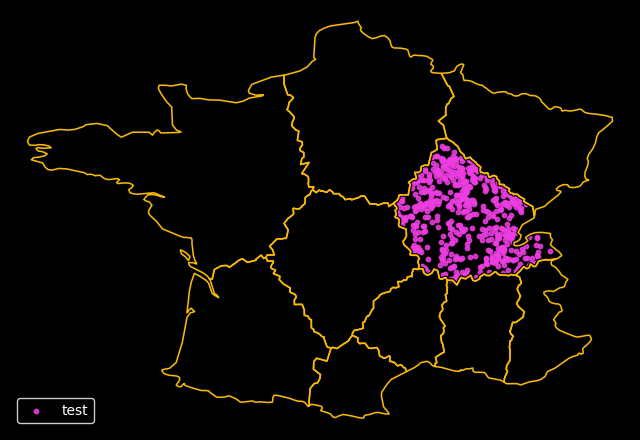

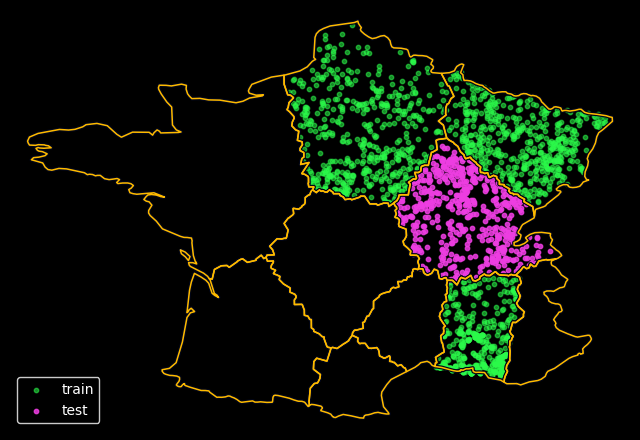

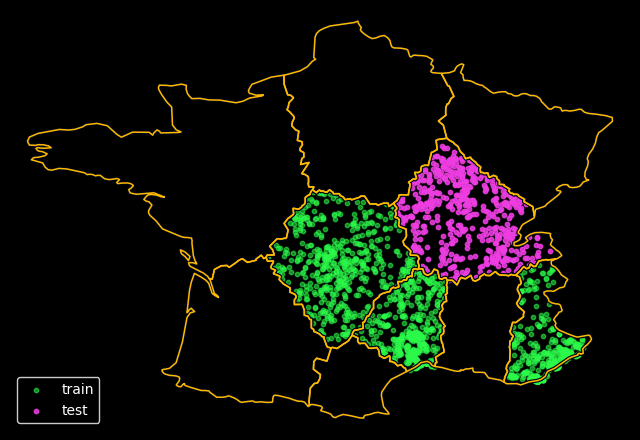

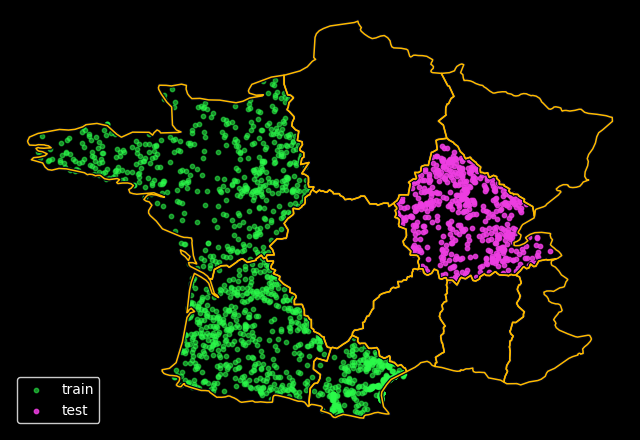

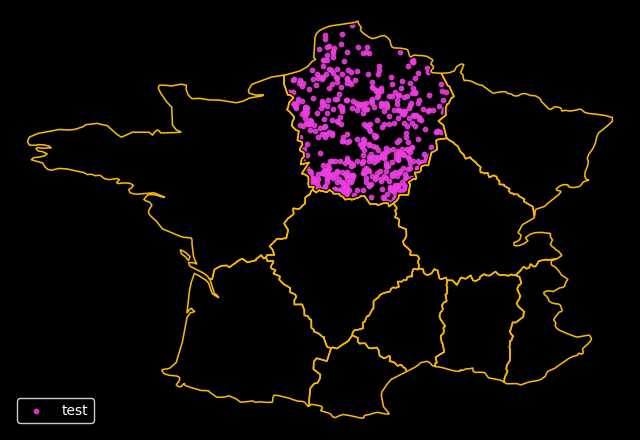

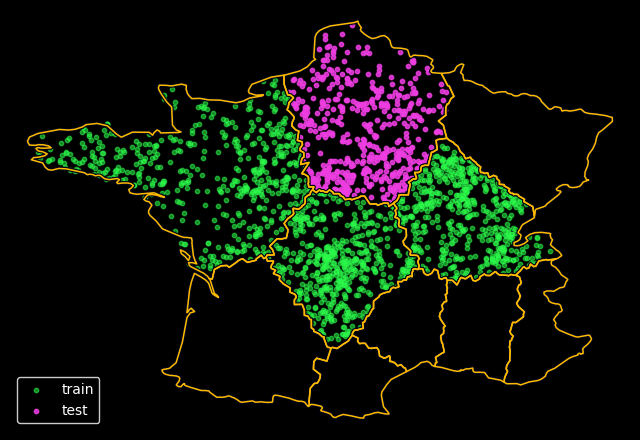

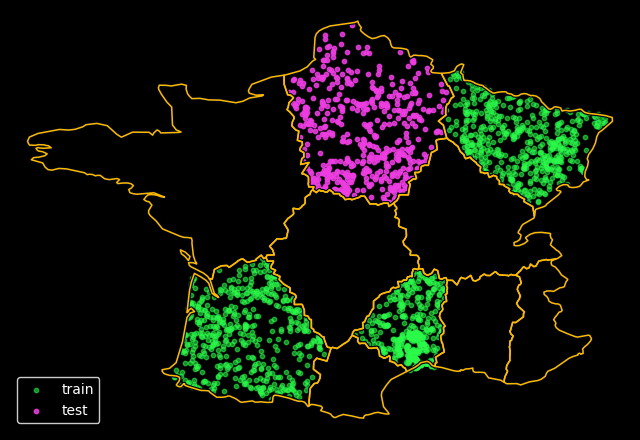

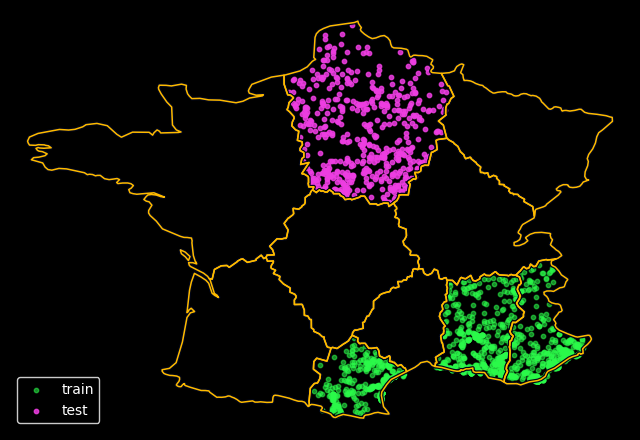

In [33]:
# select subset of unique labels to reduce number of splits (these are for test, at random)

dark_version = True

# centroids calculation using covs_distance
centroids = np.array([X_pa[covs_distance].iloc[labels == i].mean(axis=0) for i in range(K_clusters)])

D_centroids = pairwise_distances(
    centroids,
    metric='euclidean'
)


unique_labels = np.unique(labels)
select_subset = 2

selected_labels = np.random.choice(unique_labels, size=select_subset, replace=False)

clusters_in_train = int((K_clusters -1) * .34)
print(f"Using {clusters_in_train} clusters in train set.")

for test_ix in selected_labels:
    # select the closests clusters to test_ix to form train set using D_centroids
    dists_to_test = D_centroids[test_ix].copy()
    dists_to_test[test_ix] = np.inf  # ignore self-distance

    # one with the closests clusters_in_train, one with the middle clusters_in_train, one with the farthest clusters_in_train
    for option in ['closest', 'middle', 'farthest']:
        if option == 'closest':
            train_ixs = np.argsort(dists_to_test)[:clusters_in_train]
        elif option == 'middle':
            sorted_ixs = np.argsort(dists_to_test)
            start_ix = (K_clusters - clusters_in_train) // 2
            train_ixs = sorted_ixs[start_ix:start_ix + clusters_in_train]
        elif option == 'farthest':
            sorted_ixs = np.argsort(dists_to_test)[::-1]
            train_ixs = sorted_ixs[:clusters_in_train+1] # it will include test_ix, so we remove it next
        
        # remove test_ix from train_ixs if present
        train_ixs = train_ixs[train_ixs != test_ix]

        test_mask = (labels == test_ix)
        train_mask = np.isin(labels, train_ixs)
        A = np.where(test_mask)[0]
        B = np.where(train_mask)[0]
        X_pa_tr = X_pa.iloc[B]
        X_pa_te = X_pa.iloc[A]

        if option == 'closest':
            plot_clusters_with_borders(
                gdf_map,
                gdf_cluster_polys,
                train_df=None,
                test_df=X_pa_te,
                dark_version=dark_version,
                path_save=f"figures_presentation/france_geoplant_test_cluster_{test_ix}.png",
            )
        
        plot_clusters_with_borders(
            gdf_map,
            gdf_cluster_polys,
            train_df=X_pa_tr,
            test_df=X_pa_te,
            dark_version=dark_version,
            path_save=f"figures_presentation/france_geoplant_train_test_cluster_{test_ix}_{option}.png",
        )

